<a href="https://colab.research.google.com/github/adityahadagalle/Machine_learning_projects/blob/main/Flight_predctionipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_excel("Data_Train.xlsx")
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [ ]:
df.duplicated().sum()

np.int64(220)

In [ ]:
df.drop_duplicates(inplace=True)

In [ ]:
df.shape

(10463, 11)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10463 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10463 non-null  object
 1   Date_of_Journey  10463 non-null  object
 2   Source           10463 non-null  object
 3   Destination      10463 non-null  object
 4   Route            10462 non-null  object
 5   Dep_Time         10463 non-null  object
 6   Arrival_Time     10463 non-null  object
 7   Duration         10463 non-null  object
 8   Total_Stops      10462 non-null  object
 9   Additional_Info  10463 non-null  object
 10  Price            10463 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 980.9+ KB


In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


In [ ]:
df.dropna(inplace=True)

In [ ]:
df.isnull().sum()

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [ ]:
for col in df.columns:
  print(df[col].value_counts())


Airline
Jet Airways                          3700
IndiGo                               2043
Air India                            1694
Multiple carriers                    1196
SpiceJet                              815
Vistara                               478
Air Asia                              319
GoAir                                 194
Multiple carriers Premium economy      13
Jet Airways Business                    6
Vistara Premium economy                 3
Trujet                                  1
Name: count, dtype: int64
Date_of_Journey
6/06/2019     490
18/05/2019    486
9/06/2019     485
12/06/2019    483
21/05/2019    482
9/05/2019     466
21/03/2019    412
15/05/2019    402
27/05/2019    369
27/06/2019    339
24/06/2019    330
1/06/2019     330
3/06/2019     326
15/06/2019    314
24/03/2019    314
6/03/2019     302
27/03/2019    290
24/05/2019    286
6/05/2019     281
1/05/2019     274
12/05/2019    259
1/04/2019     256
3/03/2019     217
9/03/2019     199
15/03/2019    

In [ ]:
df["Date_of_Journey"]

,Date_of_Journey
0,24/03/2019
1,1/05/2019
2,9/06/2019
3,12/05/2019
4,01/03/2019
...,...
10678,9/04/2019
10679,27/04/2019
10680,27/04/2019
10681,01/03/2019


In [ ]:
df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"])

/tmp/ipykernel_6209/1954500797.py:1: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date_of_Journey"] = pd.to_datetime(df["Date_of_Journey"])


In [ ]:
df["Date_of_Journey"]

,Date_of_Journey
0,2019-03-24
1,2019-05-01
2,2019-06-09
3,2019-05-12
4,2019-03-01
...,...
10678,2019-04-09
10679,2019-04-27
10680,2019-04-27
10681,2019-03-01


In [ ]:
df["journey_day"]=df["Date_of_Journey"].dt.day
df["journey_month"]=df["Date_of_Journey"].dt.month
df["journey_year"]=df["Date_of_Journey"].dt.year

In [ ]:
df=df.drop(columns=["Date_of_Journey"])

In [ ]:
# Step 1
df["Total_Stops"] = df["Total_Stops"].str.replace("non-stop", "0")

# Step 2
df["Total_Stops"] = df["Total_Stops"].str.extract(r"(\d+)")

# Step 3
df["Total_Stops"] = df["Total_Stops"].astype(int)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Source           10462 non-null  object
 2   Destination      10462 non-null  object
 3   Route            10462 non-null  object
 4   Dep_Time         10462 non-null  object
 5   Arrival_Time     10462 non-null  object
 6   Duration         10462 non-null  object
 7   Total_Stops      10462 non-null  int64 
 8   Additional_Info  10462 non-null  object
 9   Price            10462 non-null  int64 
 10  journey_day      10462 non-null  int32 
 11  journey_month    10462 non-null  int32 
 12  journey_year     10462 non-null  int32 
dtypes: int32(3), int64(2), object(8)
memory usage: 1021.7+ KB


In [ ]:
df

,Airline,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_year
0,IndiGo,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,0,No info,3897,24,3,2019
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2,No info,7662,1,5,2019
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2,No info,13882,9,6,2019
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1,No info,6218,12,5,2019
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1,No info,13302,1,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,0,No info,4107,9,4,2019
10679,Air India,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,0,No info,4145,27,4,2019
10680,Jet Airways,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,0,No info,7229,27,4,2019
10681,Vistara,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,0,No info,12648,1,3,2019


In [ ]:
df["Duration"].unique()

array(['2h 50m', '7h 25m', '19h', '5h 25m', '4h 45m', '2h 25m', '15h 30m',
       '21h 5m', '25h 30m', '7h 50m', '13h 15m', '2h 35m', '2h 15m',
       '12h 10m', '26h 35m', '4h 30m', '22h 35m', '23h', '20h 35m',
       '5h 10m', '15h 20m', '2h 55m', '13h 20m', '15h 10m', '5h 45m',
       '5h 55m', '13h 25m', '22h', '5h 30m', '10h 25m', '5h 15m',
       '2h 30m', '6h 15m', '11h 55m', '11h 5m', '8h 30m', '22h 5m',
       '2h 45m', '12h', '16h 5m', '19h 55m', '3h 15m', '25h 20m', '3h',
       '16h 15m', '15h 5m', '6h 30m', '25h 5m', '12h 25m', '27h 20m',
       '10h 15m', '10h 30m', '1h 30m', '1h 25m', '26h 30m', '7h 20m',
       '13h 30m', '5h', '19h 5m', '14h 50m', '2h 40m', '22h 10m',
       '9h 35m', '10h', '21h 20m', '18h 45m', '12h 20m', '18h', '9h 15m',
       '17h 30m', '16h 35m', '12h 15m', '7h 30m', '24h', '8h 55m',
       '7h 10m', '14h 30m', '30h 20m', '15h', '12h 45m', '10h 10m',
       '15h 25m', '14h 5m', '20h 15m', '23h 10m', '18h 10m', '16h',
       '2h 20m', '8h', '16h 5

In [ ]:
df['Hours'] = df['Duration'].str.extract('(\d+)h')
df['Minutes'] = df['Duration'].str.extract('(\d+)m')
df['Hours'] = df['Hours'].fillna(0).astype(int)
df['Minutes'] = df['Minutes'].fillna(0).astype(int)
df["Total_minutes"]=df['Hours']*60+df['Minutes']
df=df.drop(columns=["Minutes","Hours","Duration"])

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_6209/228038833.py:1: SyntaxWarning: invalid escape sequence '\d'
  df['Hours'] = df['Duration'].str.extract('(\d+)h')
/tmp/ipykernel_6209/228038833.py:2: SyntaxWarning: invalid escape sequence '\d'
  df['Minutes'] = df['Duration'].str.extract('(\d+)m')


In [ ]:
df["Dep_hour"]=df["Dep_Time"].str.split(":").str[0].astype(int)
df["Dep_min"]=df["Dep_Time"].str.split(":").str[1].astype(int)
df=df.drop(columns="Dep_Time")

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10462 non-null  object
 1   Source           10462 non-null  object
 2   Destination      10462 non-null  object
 3   Route            10462 non-null  object
 4   Arrival_Time     10462 non-null  object
 5   Total_Stops      10462 non-null  int64 
 6   Additional_Info  10462 non-null  object
 7   Price            10462 non-null  int64 
 8   journey_day      10462 non-null  int32 
 9   journey_month    10462 non-null  int32 
 10  journey_year     10462 non-null  int32 
 11  Total_minutes    10462 non-null  int64 
 12  Dep_hour         10462 non-null  int64 
 13  Dep_min          10462 non-null  int64 
dtypes: int32(3), int64(5), object(6)
memory usage: 1.3+ MB


In [ ]:
df["Arrival_Time"]=df["Arrival_Time"].str.split(" ").str[0]
df["Arrival_Time"]

,Arrival_Time
0,01:10
1,13:15
2,04:25
3,23:30
4,21:35
...,...
10678,22:25
10679,23:20
10680,11:20
10681,14:10


In [ ]:
df["arr_hour"]=df["Arrival_Time"].str.split(":").str[0].astype(int)
df["arr_min"]=df["Arrival_Time"].str.split(":").str[1].astype(int)
df=df.drop(columns="Arrival_Time")

In [ ]:
df

,Airline,Source,Destination,Route,Total_Stops,Additional_Info,Price,journey_day,journey_month,journey_year,Total_minutes,Dep_hour,Dep_min,arr_hour,arr_min
0,IndiGo,Banglore,New Delhi,BLR → DEL,0,No info,3897,24,3,2019,170,22,20,1,10
1,Air India,Kolkata,Banglore,CCU → IXR → BBI → BLR,2,No info,7662,1,5,2019,445,5,50,13,15
2,Jet Airways,Delhi,Cochin,DEL → LKO → BOM → COK,2,No info,13882,9,6,2019,1140,9,25,4,25
3,IndiGo,Kolkata,Banglore,CCU → NAG → BLR,1,No info,6218,12,5,2019,325,18,5,23,30
4,IndiGo,Banglore,New Delhi,BLR → NAG → DEL,1,No info,13302,1,3,2019,285,16,50,21,35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,CCU → BLR,0,No info,4107,9,4,2019,150,19,55,22,25
10679,Air India,Kolkata,Banglore,CCU → BLR,0,No info,4145,27,4,2019,155,20,45,23,20
10680,Jet Airways,Banglore,Delhi,BLR → DEL,0,No info,7229,27,4,2019,180,8,20,11,20
10681,Vistara,Banglore,New Delhi,BLR → DEL,0,No info,12648,1,3,2019,160,11,30,14,10


In [ ]:
df["Route_split"] = df["Route"].str.split("→")
df["Stop_1"] = df["Route_split"].str[1]
df["Stop_2"] = df["Route_split"].str[2]
df["Stop_3"] = df["Route_split"].str[3]

In [ ]:
df["Stop_1"] = df["Stop_1"].fillna("No_Stop")
df["Stop_2"] = df["Stop_2"].fillna("No_Stop")
df["Stop_3"] = df["Stop_3"].fillna("No_Stop")

In [ ]:
df["Stop_1"] = df["Stop_1"].map(df["Stop_1"].value_counts())
df["Stop_2"] = df["Stop_2"].map(df["Stop_2"].value_counts())
df["Stop_3"] = df["Stop_3"].map(df["Stop_3"].value_counts())

# Step 5: Drop unnecessary columns
df = df.drop(columns=["Route", "Route_split","Additional_Info"])

In [ ]:
df["Destination"].value_counts()

,count
Destination,
Cochin,4345
Banglore,2860
Delhi,1265
New Delhi,914
Hyderabad,697
Kolkata,381


(array([1.0199e+04, 2.4700e+02, 8.0000e+00, 7.0000e+00, 1.0000e+00]),
 array([ 1759. , 17309.6, 32860.2, 48410.8, 63961.4, 79512. ]),
 <BarContainer object of 5 artists>)

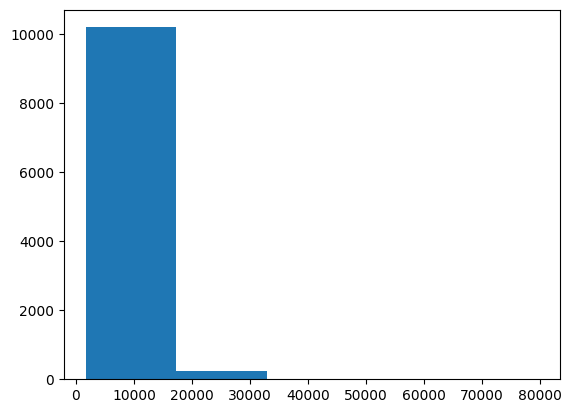

In [ ]:
import matplotlib.pyplot as plt
plt.hist(df['Price'],bins=5)

In [ ]:
df["Price"].skew()

np.float64(1.8574899082173875)

In [ ]:
import numpy as np
df["Price"] = np.log(df["Price"])

In [ ]:
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(col, "→", len(outliers))

Total_Stops → 44
Price → 9
journey_day → 0
journey_month → 0
journey_year → 0
Total_minutes → 75
Dep_hour → 0
Dep_min → 0
arr_hour → 0
arr_min → 0
Stop_1 → 0
Stop_2 → 0
Stop_3 → 1362


/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


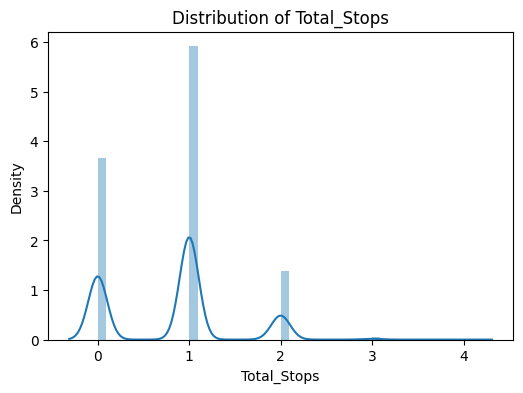

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


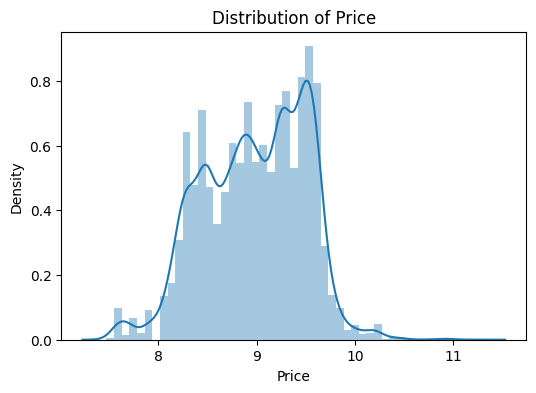

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


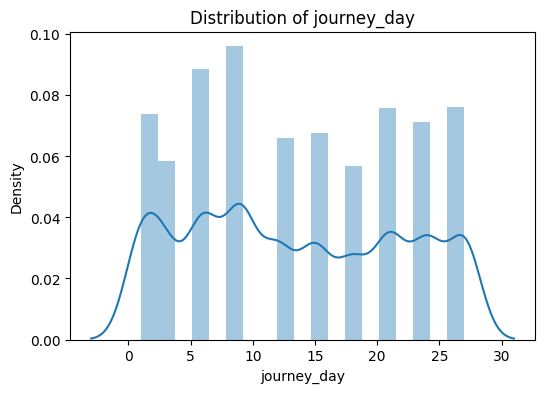

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


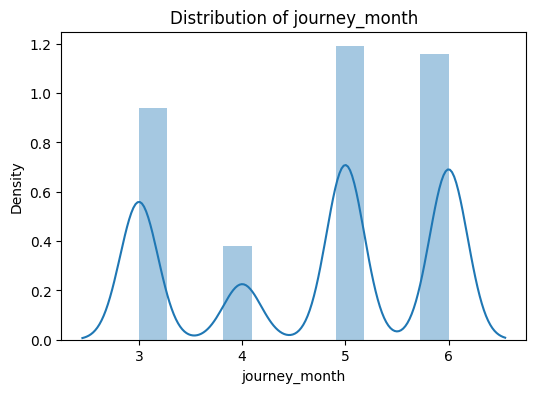

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)
/usr/local/lib/python3.12/dist-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)


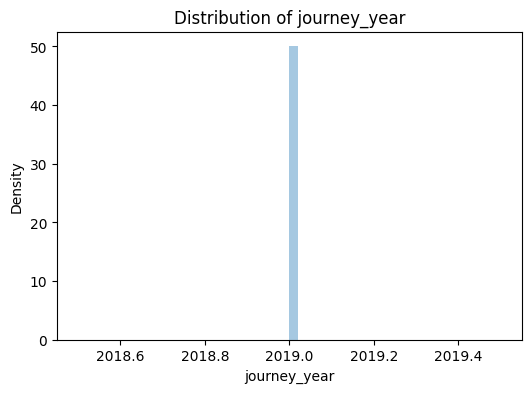

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


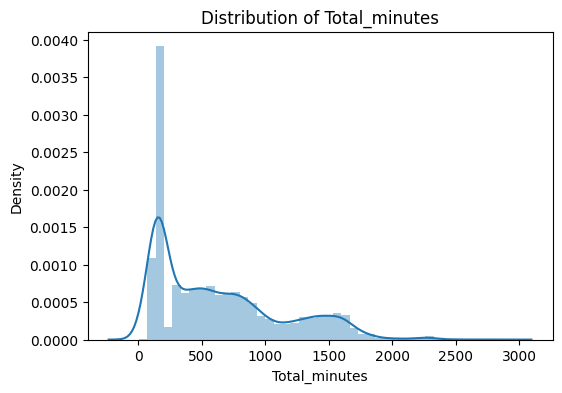

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


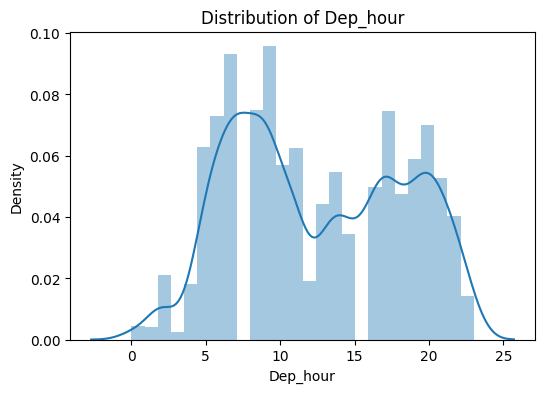

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


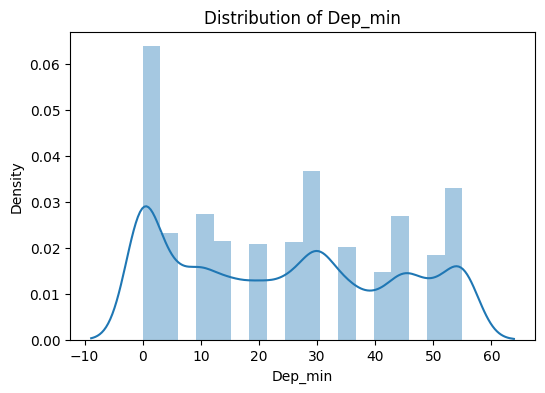

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


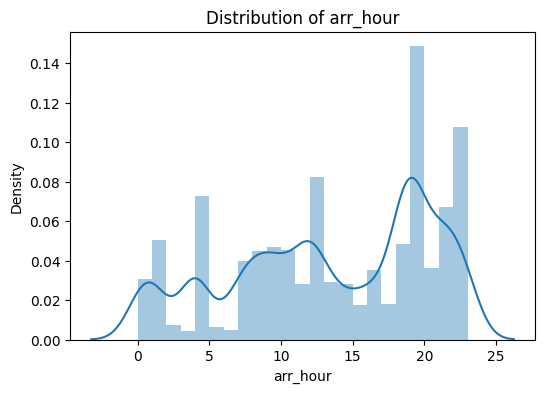

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


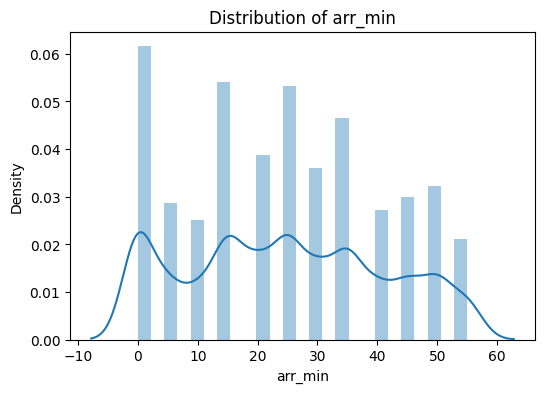

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


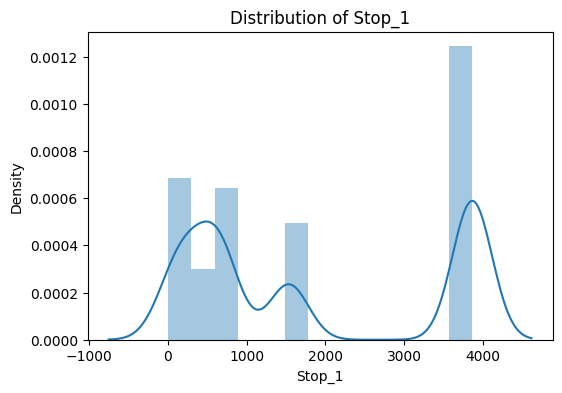

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


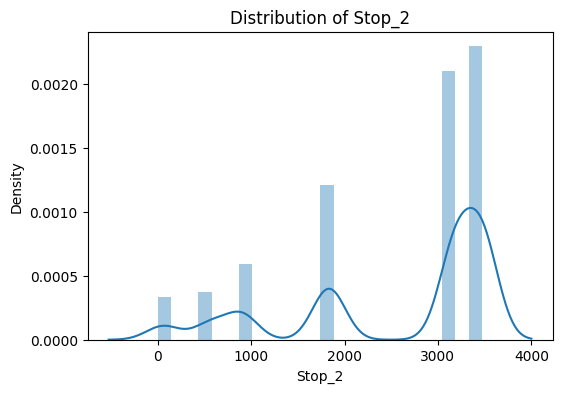

/tmp/ipykernel_6209/537870660.py:9: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df[col], kde=True)


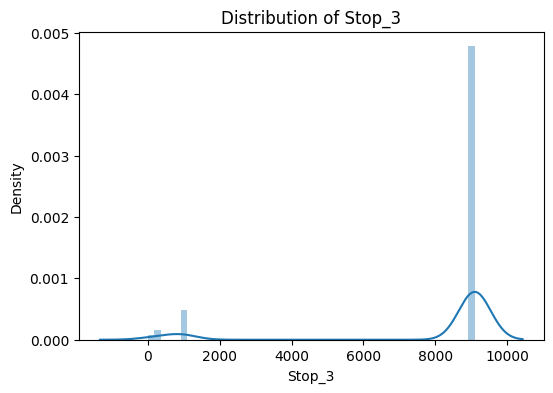

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.distplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

In [ ]:
df=df.drop(columns=["journey_year"])


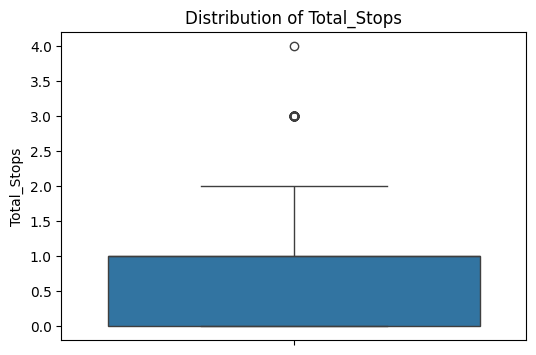

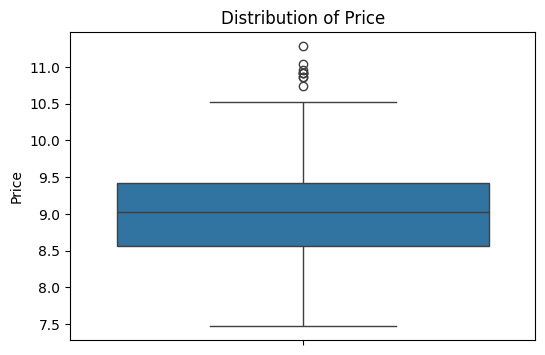

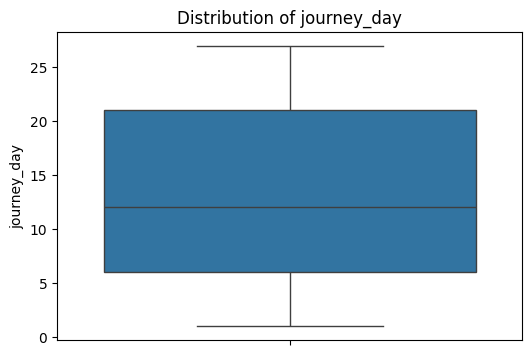

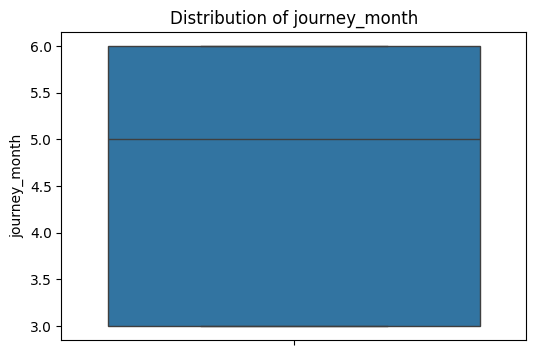

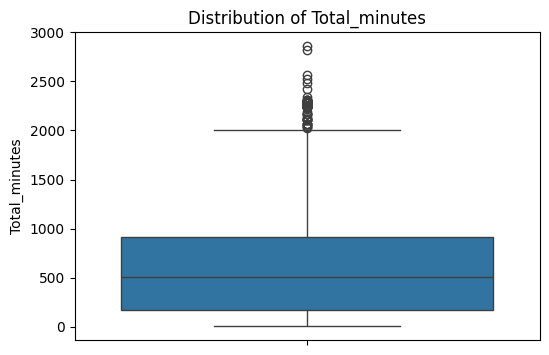

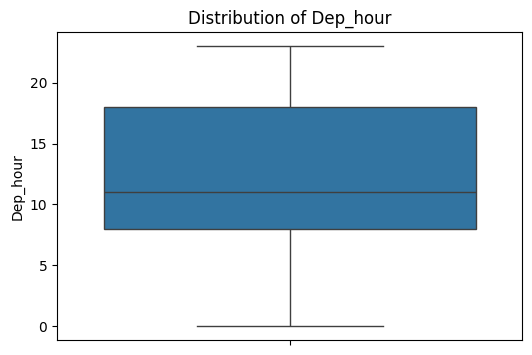

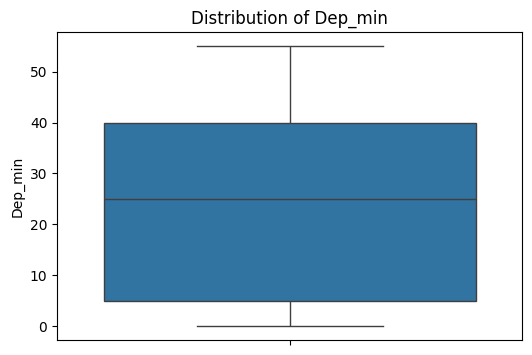

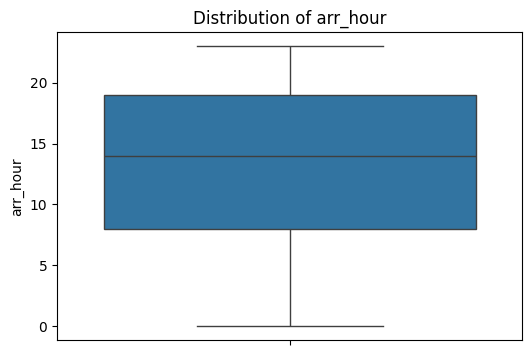

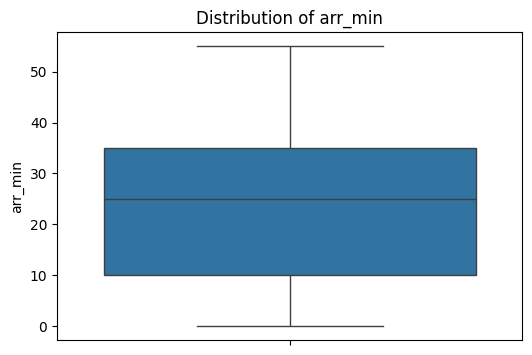

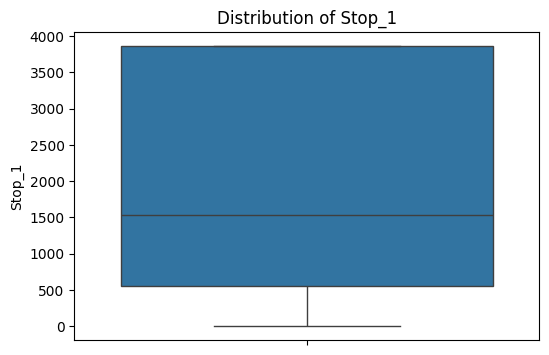

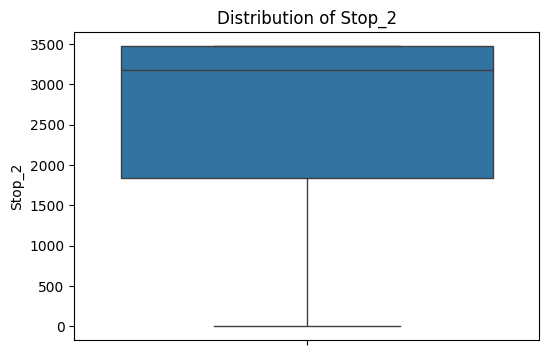

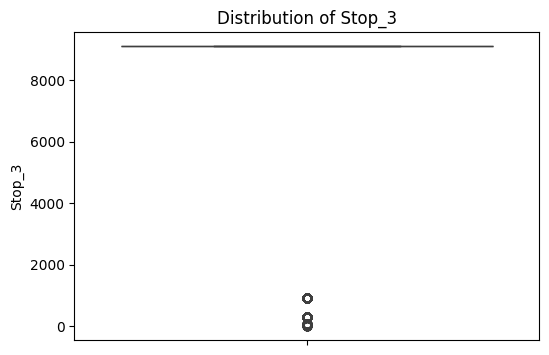

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(df[col])
    plt.title(f"Distribution of {col}")
    plt.show()

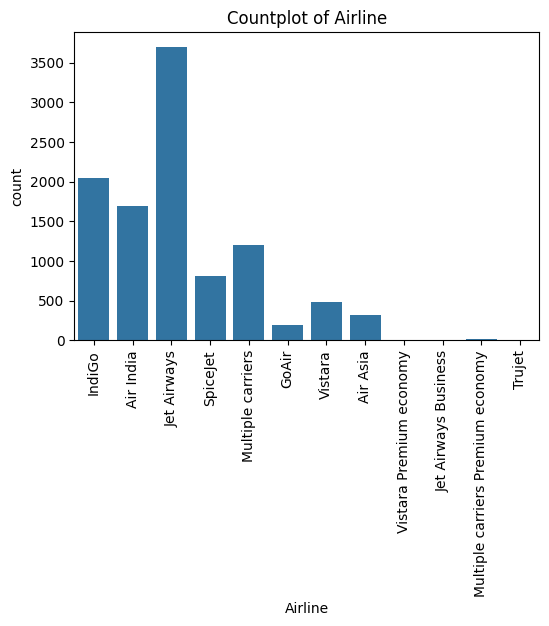

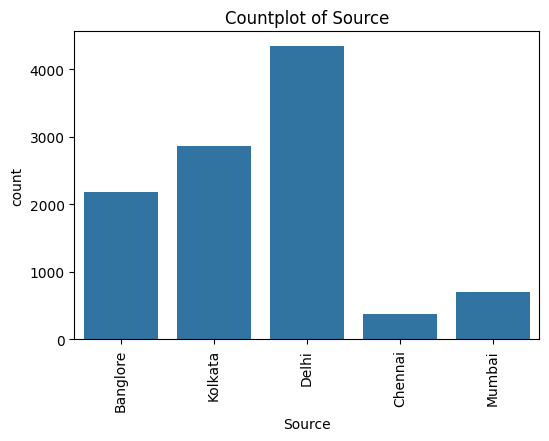

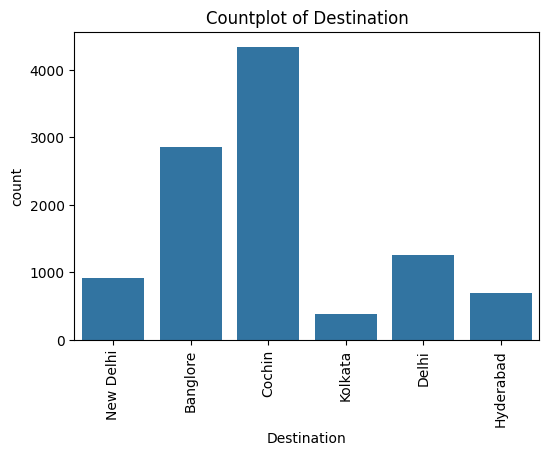

In [ ]:
cat_cols = df.select_dtypes(include="object").columns
import matplotlib.pyplot as plt
import seaborn as sns

for col in cat_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
    plt.xticks(rotation=90)
    plt.show()

In [ ]:
df.info(0)

<class 'pandas.core.frame.DataFrame'>
Index: 10462 entries, 0 to 10682
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Airline        10462 non-null  object 
 1   Source         10462 non-null  object 
 2   Destination    10462 non-null  object 
 3   Total_Stops    10462 non-null  int64  
 4   Price          10462 non-null  float64
 5   journey_day    10462 non-null  int32  
 6   journey_month  10462 non-null  int32  
 7   Total_minutes  10462 non-null  int64  
 8   Dep_hour       10462 non-null  int64  
 9   Dep_min        10462 non-null  int64  
 10  arr_hour       10462 non-null  int64  
 11  arr_min        10462 non-null  int64  
 12  Stop_1         10462 non-null  int64  
 13  Stop_2         10462 non-null  int64  
 14  Stop_3         10462 non-null  int64  
dtypes: float64(1), int32(2), int64(9), object(3)
memory usage: 1.4+ MB


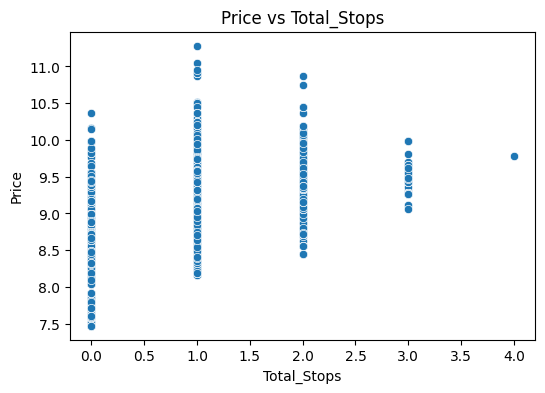

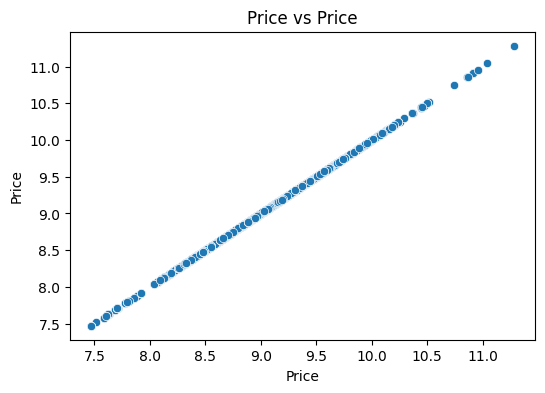

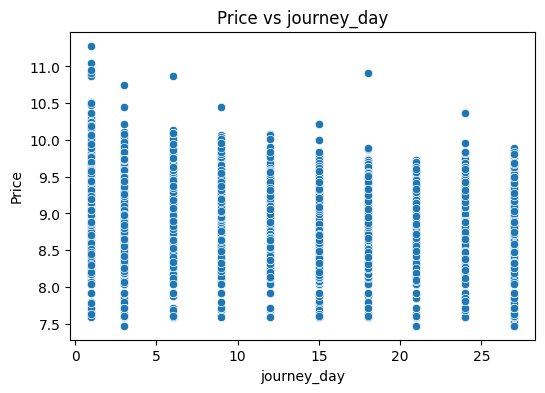

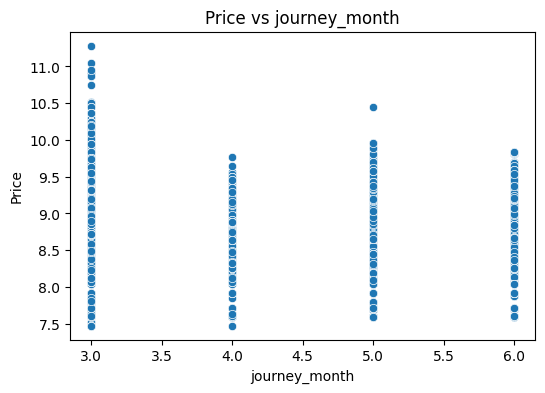

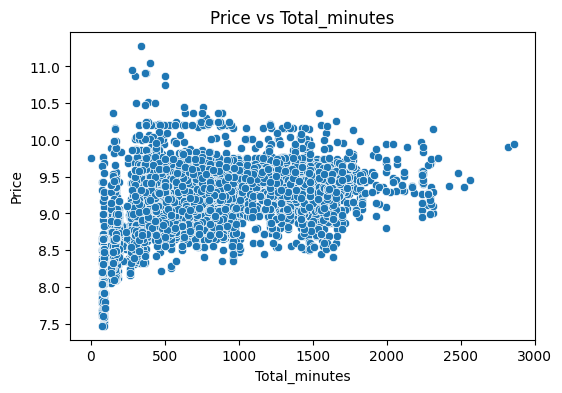

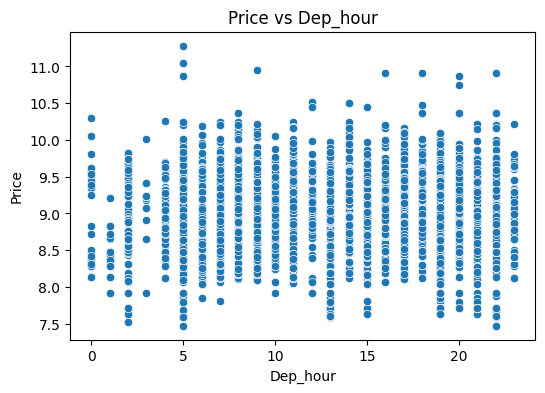

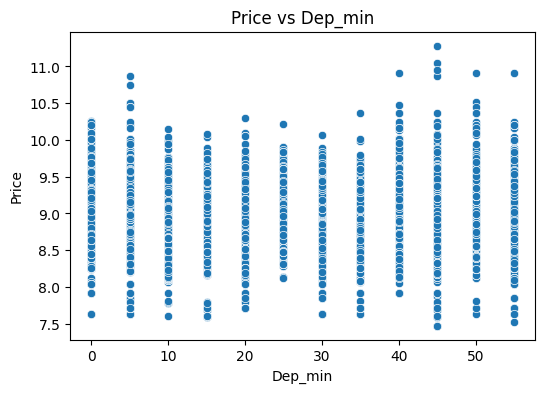

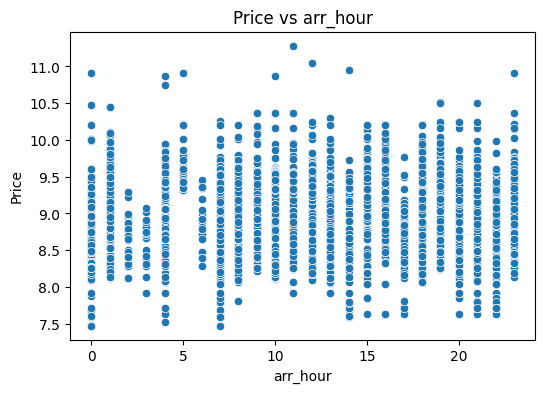

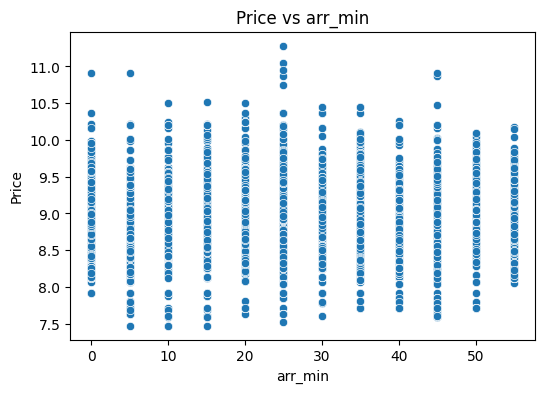

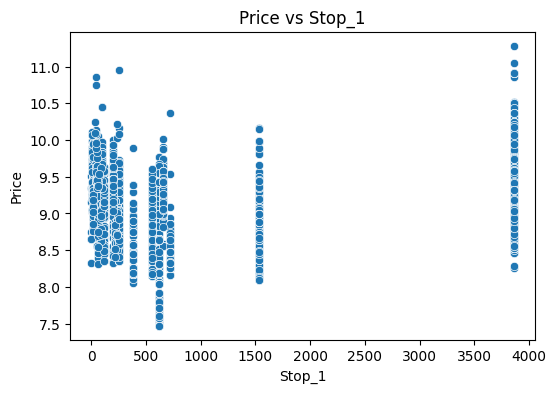

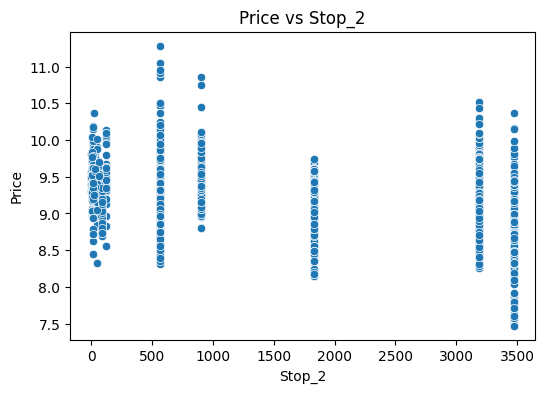

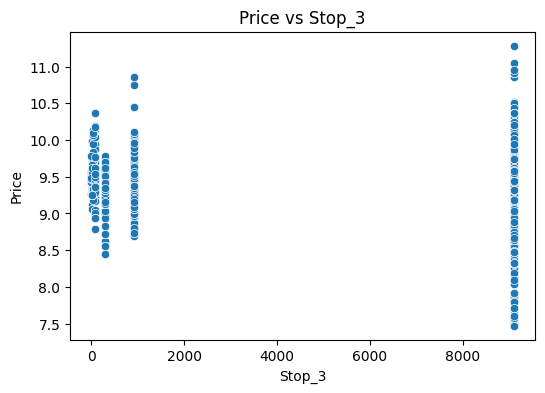

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# List of features to compare with Price
features =df.select_dtypes(include="number").columns

for col in features:
    plt.figure(figsize=(6,4))
    sns.scatterplot(x=df[col], y=df["Price"])
    plt.title(f"Price vs {col}")
    plt.xlabel(col)
    plt.ylabel("Price")
    plt.show()

/tmp/ipykernel_6209/2154465487.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Price', data=df, ci=None)  # ci=None removes error bars
/tmp/ipykernel_6209/2154465487.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Price', data=df, ci=None)  # ci=None removes error bars
/tmp/ipykernel_6209/2154465487.py:15: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x=col, y='Price', data=df, ci=None)  # ci=None removes error bars


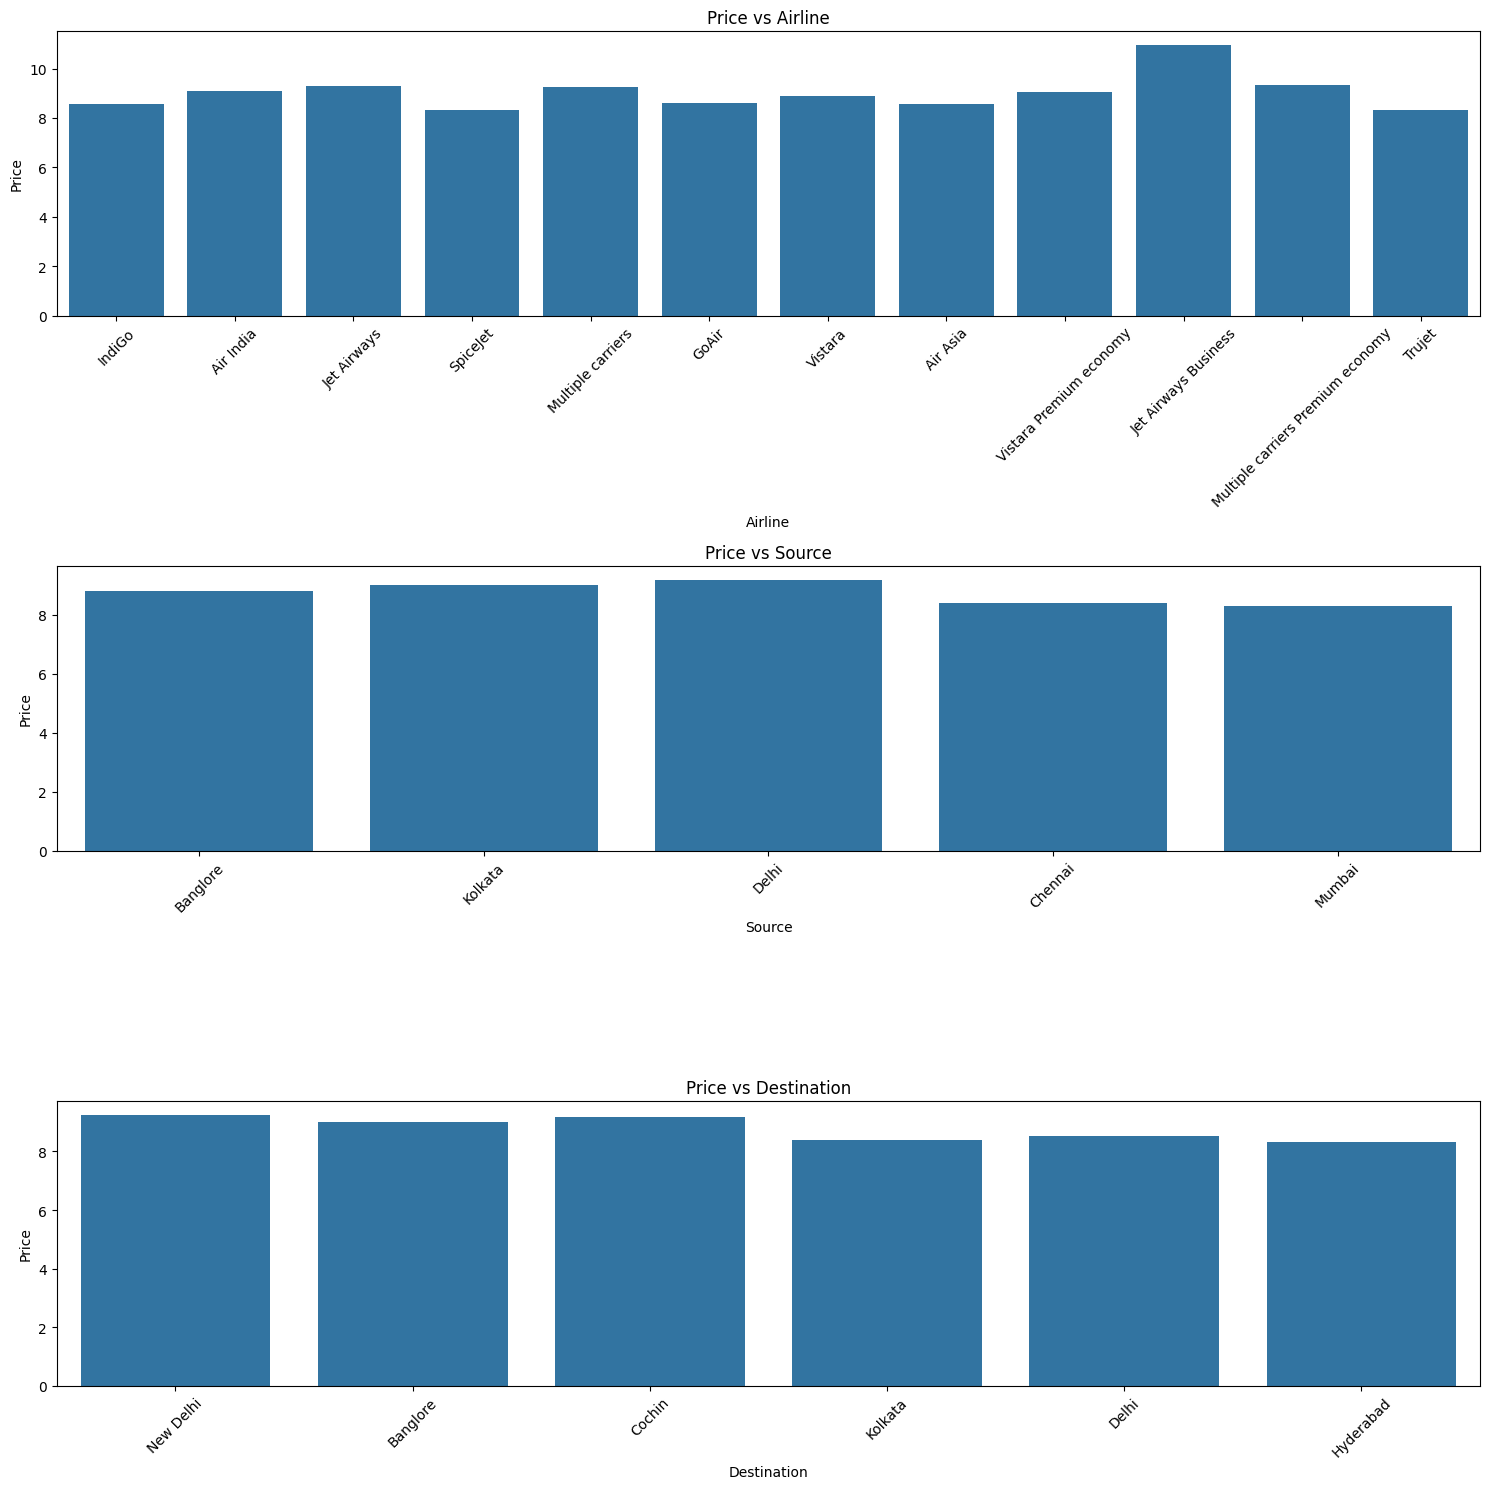

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# assuming your dataset is loaded as df
# df = pd.read_csv('your_file.csv')

# identify categorical columns (excluding 'Price')
categorical_cols = df.select_dtypes(include='object').columns

# plotting barplots
plt.figure(figsize=(15, 5*len(categorical_cols)))  # adjust figure size
for i, col in enumerate(categorical_cols, 1):
    plt.subplot(len(categorical_cols), 1, i)
    sns.barplot(x=col, y='Price', data=df, ci=None)  # ci=None removes error bars
    plt.xticks(rotation=45)
    plt.title(f'Price vs {col}')
plt.tight_layout()
plt.show()

In [ ]:
df

,Airline,Source,Destination,Total_Stops,Price,journey_day,journey_month,Total_minutes,Dep_hour,Dep_min,arr_hour,arr_min,Stop_1,Stop_2,Stop_3
0,IndiGo,Banglore,New Delhi,0,8.267962,24,3,170,22,20,1,10,1536,3475,9100
1,Air India,Kolkata,Banglore,2,8.944028,1,5,445,5,50,13,15,52,14,291
2,Jet Airways,Delhi,Cochin,2,9.538348,9,6,1140,9,25,4,25,61,899,924
3,IndiGo,Kolkata,Banglore,1,8.735204,12,5,325,18,5,23,30,56,1834,9100
4,IndiGo,Banglore,New Delhi,1,9.495670,1,3,285,16,50,21,35,56,562,9100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,0,8.320448,9,4,150,19,55,22,25,724,3475,9100
10679,Air India,Kolkata,Banglore,0,8.329658,27,4,155,20,45,23,20,724,3475,9100
10680,Jet Airways,Banglore,Delhi,0,8.885856,27,4,180,8,20,11,20,1536,3475,9100
10681,Vistara,Banglore,New Delhi,0,9.445254,1,3,160,11,30,14,10,1536,3475,9100


In [ ]:
df = df.drop(['Stop_1','Stop_2','Stop_3'], axis=1)


In [ ]:
# # =============================
# # Flight Price Prediction Pipeline (Fixed)
# # =============================

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import mean_squared_error
# from sklearn.linear_model import LinearRegression
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# # 1️⃣ Load dataset
# # df = pd.read_csv('flight_data.csv')  # replace with your file path

# # 2️⃣ Identify features
# target = 'Price'
# categorical_cols = ['Airline', 'Source', 'Destination', 'Total_Stops']
# numerical_cols = ['journey_day', 'journey_month', 'Total_minutes',
#                   'Dep_hour', 'Dep_min', 'arr_hour', 'arr_min']

# # 3️⃣ Optional: Handle stops with rare categories
# # Cap Total_Stops at 3 to avoid unseen categories in test set
# df['Total_Stops'] = df['Total_Stops'].apply(lambda x: 3 if x > 3 else x)

# # 4️⃣ Convert categorical columns to string
# for col in categorical_cols:
#     df[col] = df[col].astype(str)

# # 5️⃣ Split features and target
# X = df[categorical_cols + numerical_cols]
# y = df[target]

# # 6️⃣ Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # 7️⃣ Preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_cols),
#         ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
#     ]
# )

# # 8️⃣ Define models
# models = {
#     'LinearRegression': LinearRegression(),
#     'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42),
#     'XGBoost': xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
# }

# # 9️⃣ Train and evaluate models
# for name, model in models.items():
#     pipeline = Pipeline([
#         ('preprocessor', preprocessor),
#         ('model', model)
#     ])

#     # Fit model
#     pipeline.fit(X_train, y_train)

#     # Predict
#     y_pred = pipeline.predict(X_test)

#     # Evaluate
#     rmse = np.sqrt(mean_squared_error(y_test, y_pred))
#     print(f"{name} RMSE: {rmse:.4f}")

In [ ]:
# # =============================
# # Hyperparameter Tuning for Flight Price Prediction
# # =============================

# import pandas as pd
# import numpy as np
# from sklearn.model_selection import train_test_split, GridSearchCV
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.metrics import mean_squared_error
# from sklearn.ensemble import RandomForestRegressor
# import xgboost as xgb

# # 1️⃣ Load dataset
# # df = pd.read_csv('flight_data.csv')  # replace with your file path

# # 2️⃣ Identify features
# target = 'Price'
# categorical_cols = ['Airline', 'Source', 'Destination', 'Total_Stops']
# numerical_cols = ['journey_day', 'journey_month', 'Total_minutes',
#                   'Dep_hour', 'Dep_min', 'arr_hour', 'arr_min']

# # 3️⃣ Handle rare Total_Stops
# df['Total_Stops'] = df['Total_Stops'].apply(lambda x: 3 if x > 3 else x)

# # 4️⃣ Convert categorical columns to string
# for col in categorical_cols:
#     df[col] = df[col].astype(str)

# # 5️⃣ Split features and target
# X = df[categorical_cols + numerical_cols]
# y = df[target]

# # 6️⃣ Train-test split
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, random_state=42
# )

# # 7️⃣ Preprocessing pipeline
# preprocessor = ColumnTransformer(
#     transformers=[
#         ('num', StandardScaler(), numerical_cols),
#         ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
#     ]
# )

# # =============================
# # Random Forest Hyperparameter Tuning
# # =============================

# rf_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', RandomForestRegressor(random_state=42))
# ])

# rf_param_grid = {
#     'model__n_estimators': [100, 200, 300],
#     'model__max_depth': [None, 10, 20, 30],
#     'model__min_samples_split': [2, 5, 10]
# }

# rf_grid = GridSearchCV(
#     rf_pipeline,
#     param_grid=rf_param_grid,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# rf_grid.fit(X_train, y_train)
# print("Best RF params:", rf_grid.best_params_)

# # Predict and evaluate
# y_pred_rf = rf_grid.predict(X_test)
# rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
# print(f"Random Forest RMSE after tuning: {rmse_rf:.4f}")

# # =============================
# # XGBoost Hyperparameter Tuning
# # =============================

# xgb_pipeline = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', xgb.XGBRegressor(random_state=42, objective='reg:squarederror'))
# ])

# xgb_param_grid = {
#     'model__n_estimators': [100, 200, 300],
#     'model__max_depth': [3, 5, 7],
#     'model__learning_rate': [0.01, 0.05, 0.1],
#     'model__subsample': [0.7, 0.8, 1.0]
# }

# xgb_grid = GridSearchCV(
#     xgb_pipeline,
#     param_grid=xgb_param_grid,
#     cv=3,
#     scoring='neg_root_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )

# xgb_grid.fit(X_train, y_train)
# print("Best XGBoost params:", xgb_grid.best_params_)

# # Predict and evaluate
# y_pred_xgb = xgb_grid.predict(X_test)
# rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
# print(f"XGBoost RMSE after tuning: {rmse_xgb:.4f}")

Fitting 3 folds for each of 36 candidates, totalling 108 fits
Best RF params: {'model__max_depth': 20, 'model__min_samples_split': 10, 'model__n_estimators': 300}
Random Forest RMSE after tuning: 0.1776
Fitting 3 folds for each of 81 candidates, totalling 243 fits
Best XGBoost params: {'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 300, 'model__subsample': 1.0}
XGBoost RMSE after tuning: 0.1720


In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Assuming df is already preprocessed and ready
# Separate features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -----------------------------
# Random Forest with best params
# -----------------------------
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=20,
    min_samples_split=10,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

rf_rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))
rf_r2 = r2_score(y_test, y_pred_rf)

print("Random Forest RMSE:", round(rf_rmse,4))
print("Random Forest R2:", round(rf_r2,4))

# -----------------------------
# XGBoost with best params
# -----------------------------
xgb_model = XGBRegressor(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.1,
    subsample=1.0,
    random_state=42
)

xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

xgb_rmse = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("XGBoost RMSE:", round(xgb_rmse,4))
print("XGBoost R2:", round(xgb_r2,4))

In [ ]:
from sklearn.metrics import mean_squared_error

# Predict on train
y_train_pred = xgb_grid.predict(X_train)
train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))

# Predict on test
y_test_pred = xgb_grid.predict(X_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")

Train RMSE: 0.1397
Test RMSE: 0.1720


In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    xgb_grid.best_estimator_,
    X_train, y_train,
    scoring='neg_root_mean_squared_error',
    cv=5
)

print("CV RMSE Scores:", -cv_scores)
print("Mean CV RMSE:", -cv_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


CV RMSE Scores: [0.1764326  0.17298888 0.16294332 0.17145494 0.17017981]
Mean CV RMSE: 0.1707999097750606


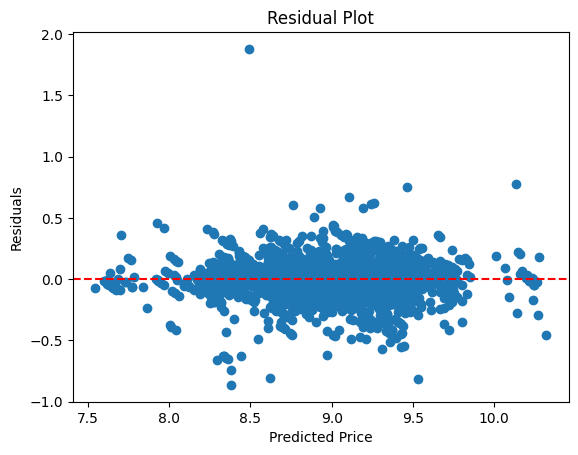

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - y_pred_xgb

plt.scatter(y_test_pred, residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Price')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

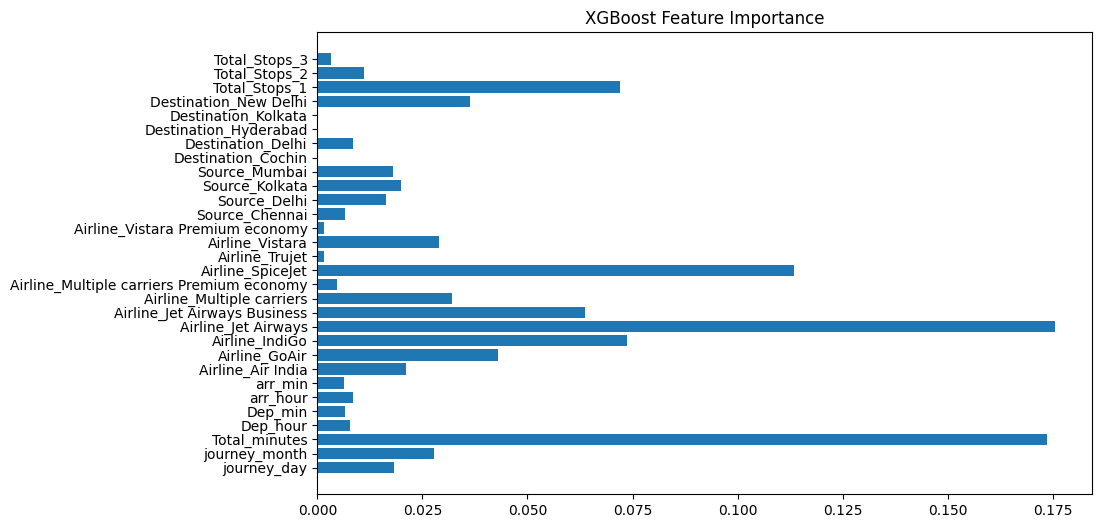

In [ ]:
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = (
    xgb_grid.best_estimator_['preprocessor']
    .transformers_[0][2] +  # numerical cols
    list(xgb_grid.best_estimator_['preprocessor']
         .transformers_[1][1]
         .get_feature_names_out(categorical_cols))
)

importances = xgb_grid.best_estimator_['model'].feature_importances_

# Plot feature importance
plt.figure(figsize=(10,6))
plt.barh(feature_names, importances)
plt.title('XGBoost Feature Importance')
plt.show()